In [4]:
import pandas as pd
import sqlite3
import os 
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
import db_mgmt as mgmt

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg


In [5]:
db_path = 'output_files/2025-12-09 1338/CANOE_geospatial.sqlite'
# db_path = '/Users/thiagorodrigues/Library/CloudStorage/OneDrive-UniversityofToronto/UofT/renewable_supply/TEMOA_Approach/data_files/temoa_basic_0.sqlite'
data = mgmt.sqlite_to_dfs(db_path)


In [6]:
sites = pd.read_csv('sites_dict_2.csv')
sites['region'] = sites['site_id']
sites.set_index('region', inplace=True)

demand = sites.loc[sites.demand != 0].copy()

flowIn = data['OutputFlowIn'].copy()
flowOut = data['OutputFlowOut'].copy()

flowOut['region_from'], flowOut['region_to'] = None, None
for i in range(len(flowOut)):
    if flowOut['region'][i] not in sites.index:
        # print(flowOut['region'][i])
        r_from, r_to = flowOut['region'][i].split('-')
        flowOut.loc[i, 'region_from'] = r_from
        flowOut.loc[i, 'region_to'] = r_to

h2_plant = flowOut.loc[flowOut.tech=='H2_PLANT'].copy()
gsl_plant = flowOut.loc[flowOut.tech=='GSL_PLANT'].copy()
meth_plant = flowOut.loc[flowOut.tech=='METH_PLANT'].copy()
gsl_demand = flowOut.loc[flowOut.tech=='GSL_DEMAND'].copy()
co2_cap = flowOut.loc[flowOut.tech=='CO2_CAP'].copy()
elc_gen = flowOut.loc[flowOut.tech=='ELC_GEN'].copy()

elc_gen.set_index('region', inplace=True)
elc_gen['lon'] = sites.loc[elc_gen.index, 'lon']
elc_gen['lat'] = sites.loc[elc_gen.index, 'lat']


h2_plant.set_index('region', inplace=True)
h2_plant['lon'] = sites.loc[h2_plant.index, 'lon']
h2_plant['lat'] = sites.loc[h2_plant.index, 'lat']

gsl_plant.set_index('region', inplace=True)
gsl_plant['lon'] = sites.loc[gsl_plant.index, 'lon']
gsl_plant['lat'] = sites.loc[gsl_plant.index, 'lat']

meth_plant.set_index('region', inplace=True)
meth_plant['lon'] = sites.loc[meth_plant.index, 'lon']     
meth_plant['lat'] = sites.loc[meth_plant.index, 'lat']

gsl_demand.set_index('region', inplace=True)
gsl_demand['lon'] = sites.loc[gsl_demand.index, 'lon']
gsl_demand['lat'] = sites.loc[gsl_demand.index, 'lat']

co2_cap.set_index('region', inplace=True)
co2_cap['lon'] = sites.loc[co2_cap.index, 'lon']
co2_cap['lat'] = sites.loc[co2_cap.index, 'lat']



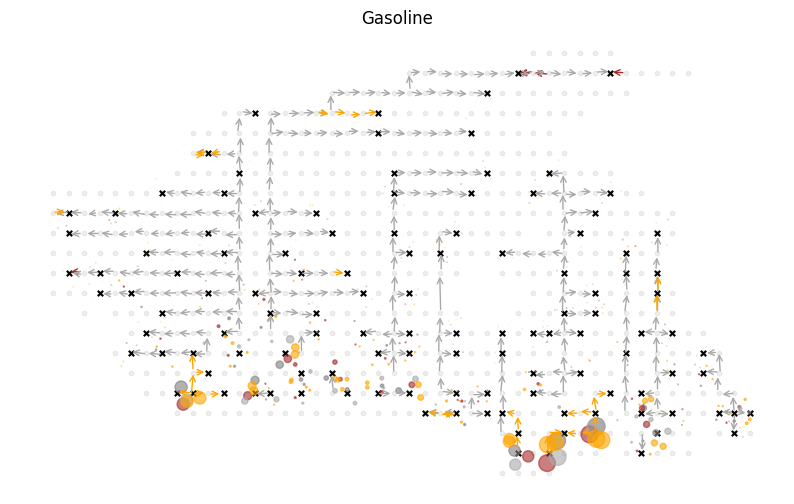

In [ ]:
db_path = 'output_files/2025-12-09 1338/CANOE_geospatial.sqlite'
# db_path = '/Users/thiagorodrigues/Library/CloudStorage/OneDrive-UniversityofToronto/UofT/renewable_supply/TEMOA_Approach/data_files/temoa_basic_0.sqlite'
data = mgmt.sqlite_to_dfs(db_path)


sites = pd.read_csv('sites_dict_2.csv')
sites['region'] = sites['site_id']
sites.set_index('region', inplace=True)

demand = sites.loc[sites.demand != 0].copy()

flowIn = data['OutputFlowIn'].copy()
flowOut = data['OutputFlowOut'].copy()

flowOut['region_from'], flowOut['region_to'] = None, None
for i in range(len(flowOut)):
    if flowOut['region'][i] not in sites.index:
        # print(flowOut['region'][i])
        r_from, r_to = flowOut['region'][i].split('-')
        flowOut.loc[i, 'region_from'] = r_from
        flowOut.loc[i, 'region_to'] = r_to

h2_plant = flowOut.loc[flowOut.tech=='H2_PLANT'].copy()
gsl_plant = flowOut.loc[flowOut.tech=='GSL_PLANT'].copy()
meth_plant = flowOut.loc[flowOut.tech=='METH_PLANT'].copy()
gsl_demand = flowOut.loc[flowOut.tech=='GSL_DEMAND'].copy()
co2_cap = flowOut.loc[flowOut.tech=='CO2_CAP'].copy()
elc_gen = flowOut.loc[flowOut.tech=='ELC_GEN'].copy()

elc_gen.set_index('region', inplace=True)
elc_gen['lon'] = sites.loc[elc_gen.index, 'lon']
elc_gen['lat'] = sites.loc[elc_gen.index, 'lat']


h2_plant.set_index('region', inplace=True)
h2_plant['lon'] = sites.loc[h2_plant.index, 'lon']
h2_plant['lat'] = sites.loc[h2_plant.index, 'lat']

gsl_plant.set_index('region', inplace=True)
gsl_plant['lon'] = sites.loc[gsl_plant.index, 'lon']
gsl_plant['lat'] = sites.loc[gsl_plant.index, 'lat']

meth_plant.set_index('region', inplace=True)
meth_plant['lon'] = sites.loc[meth_plant.index, 'lon']     
meth_plant['lat'] = sites.loc[meth_plant.index, 'lat']

gsl_demand.set_index('region', inplace=True)
gsl_demand['lon'] = sites.loc[gsl_demand.index, 'lon']
gsl_demand['lat'] = sites.loc[gsl_demand.index, 'lat']

co2_cap.set_index('region', inplace=True)
co2_cap['lon'] = sites.loc[co2_cap.index, 'lon']
co2_cap['lat'] = sites.loc[co2_cap.index, 'lat']




labels = ['co2_cap', 'gas_demand', 'gas_plant', 
          'h2_plant', 'meth_plant', 'elc_gen']

image_file = ['co2.png', 'gas_demand.png', 'gasoline_plant.png', 
              'h2.png', 'methanol.png', 'wind_turbine.png']

techs = [co2_cap, gsl_demand, gsl_plant, 
         h2_plant, meth_plant, elc_gen]
color = ['gray', 'brown', 'darkgray', 
         'blue', 'orange', 'pink']

label = ['Electricity', 'H2', 'CO2', 
         'Methanol', 'Gasoline']


h2_pipe = flowOut.loc[flowOut.tech=='H2_PIPE'].copy()
gsl_pipe = flowOut.loc[flowOut.tech=='GSL_PIPE'].copy()
meth_pipe = flowOut.loc[flowOut.tech=='METH_PIPE'].copy()
co2_pipe = flowOut.loc[flowOut.tech=='CO2_PIPE'].copy()
elc_trans = flowOut.loc[flowOut.tech=='ELC_TRANS'].copy()

techs = [elc_gen, h2_plant, co2_cap, meth_plant, gsl_plant]
transp_tech = [elc_trans, h2_pipe, co2_pipe, meth_pipe, gsl_pipe]




df = sites.loc[sites['demand']>0].copy()
df.reset_index(inplace=True)
df['demand'] = df['demand'].astype(float)
size_demand = df['demand']/df['demand'].max() * 500  # Scale sizes for visibility



fig, ax = plt.subplots(figsize=(10,6))

plt.scatter(sites['lon'], sites['lat'], c='gray', s=10, label='Region', alpha=0.12)
plt.scatter(x='lon', y='lat', data=df, s=15, color='black', label='Demand',  alpha=1, marker='x')

for i in range(len(transp_tech)):
    df = transp_tech[i]
    df['lon_from'] = df['region_from'].map(sites['lon'])
    df['lat_from'] = df['region_from'].map(sites['lat'])
    df['lon_to'] = df['region_to'].map(sites['lon'])
    df['lat_to'] = df['region_to'].map(sites['lat'])

for j in range(len(label)):
    df = techs[j].copy()

    
    
    jit = 1.5
    df.reset_index(inplace=True)
    df['flow'] = df['flow'].astype(float)
    df['lat'] += np.random.uniform(-jit, jit, size=len(df))
    df['lon'] += np.random.uniform(-jit, jit, size=len(df))
    sizes = df['flow']/df['flow'].max() * 150  # Scale sizes for visibility
    plt.scatter(x='lon', y='lat', data=df, s=sizes, color=color[j], label=label[j],  alpha=0.6)
    plt.title(label[j])
    
    df = transp_tech[j].copy()
    df.reset_index(inplace=True)
    jitter = 0.2
    for _, row in df.iterrows():
        ax.annotate(
            '',  # no text
            xy=(row['lon_to']+np.random.uniform(-jitter, jitter), row['lat_to']+np.random.uniform(-jitter,jitter)),        # arrow head
            xytext=(row['lon_from']+np.random.uniform(-0.2,0.2), row['lat_from']+np.random.uniform(-jitter,jitter)),# arrow tail
            arrowprops=dict(
                arrowstyle="->",
                color=color[j],
                lw=1,  # line width
                alpha=1
            )
        )
    sns.despine(top=True, right=True, left=True, bottom=True)
    # plt.savefig(f'figures/{label[j]}.png', dpi=300)
ax.set_xticks([])
ax.set_yticks([])


plt.show()

    

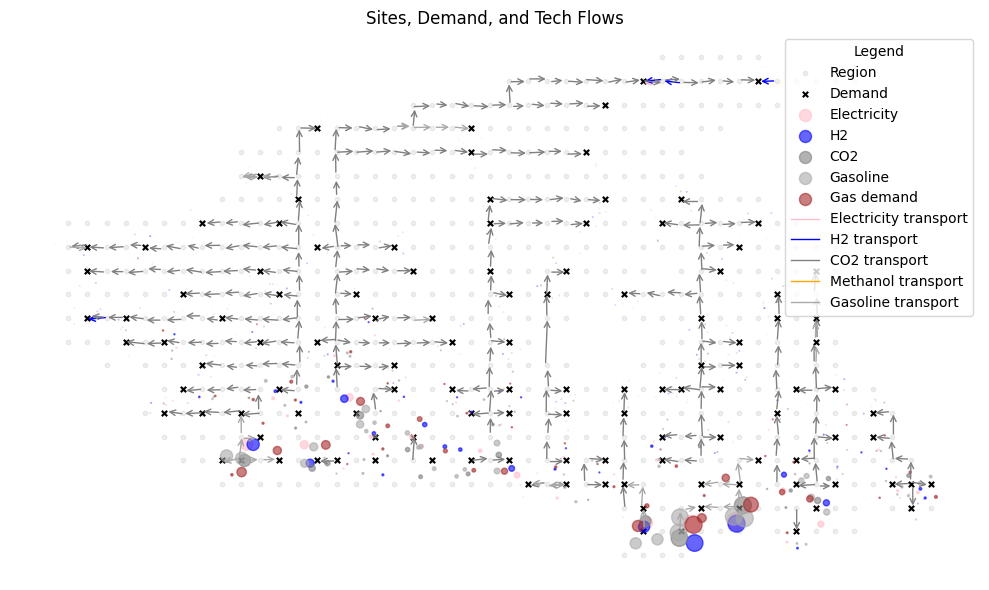

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# import seaborn as sns  # optional

# -------------------------------
# Load data
# -------------------------------
db_path = 'output_files/2025-12-09 1338/CANOE_geospatial.sqlite'
data = mgmt.sqlite_to_dfs(db_path)

sites = pd.read_csv('sites_dict_2.csv')
sites['region'] = sites['site_id']
sites = sites.set_index('region', drop=True)

flowIn  = data['OutputFlowIn'].copy()
flowOut = data['OutputFlowOut'].copy()

# -------------------------------
# Parse region_from / region_to (vectorized)
# -------------------------------
flowOut = flowOut.copy()
flowOut['region_from'] = pd.NA
flowOut['region_to']   = pd.NA

mask_pair = ~flowOut['region'].isin(sites.index)
# split like "AAA-BBB" -> ["AAA","BBB"] only where needed
split = flowOut.loc[mask_pair, 'region'].str.split('-', n=1, expand=True)
flowOut.loc[mask_pair, 'region_from'] = split[0]
flowOut.loc[mask_pair, 'region_to']   = split[1]

# -------------------------------
# Helper: add lon/lat by index (region)
# -------------------------------
def add_site_coords(df, idx_col='region'):
    """Join lon/lat from `sites` using df[idx_col] as index."""
    if idx_col != df.index.name:
        df = df.set_index(idx_col, drop=False)
    return df.join(sites[['lon', 'lat']], how='left')

# -------------------------------
# Slice techs and attach coordinates
# -------------------------------
def slice_with_coords(df, tech_name):
    out = df.loc[df['tech'] == tech_name].copy()
    out = add_site_coords(out, idx_col='region')
    return out

elc_gen   = slice_with_coords(flowOut, 'ELC_GEN')
h2_plant  = slice_with_coords(flowOut, 'H2_PLANT')
co2_cap   = slice_with_coords(flowOut, 'CO2_CAP')
meth_plant= slice_with_coords(flowOut, 'METH_PLANT')
gsl_plant = slice_with_coords(flowOut, 'GSL_PLANT')
gsl_demand= slice_with_coords(flowOut, 'GSL_DEMAND')

# Transport links
def add_from_to_coords(df_links):
    """Map lon/lat for region_from and region_to."""
    df = df_links.copy()
    df['lon_from'] = df['region_from'].map(sites['lon'])
    df['lat_from'] = df['region_from'].map(sites['lat'])
    df['lon_to']   = df['region_to'].map(sites['lon'])
    df['lat_to']   = df['region_to'].map(sites['lat'])
    return df

h2_pipe   = add_from_to_coords(flowOut.loc[flowOut.tech=='H2_PIPE'])
gsl_pipe  = add_from_to_coords(flowOut.loc[flowOut.tech=='GSL_PIPE'])
meth_pipe = add_from_to_coords(flowOut.loc[flowOut.tech=='METH_PIPE'])
co2_pipe  = add_from_to_coords(flowOut.loc[flowOut.tech=='CO2_PIPE'])
elc_trans = add_from_to_coords(flowOut.loc[flowOut.tech=='ELC_TRANS'])

# -------------------------------
# Plot config (consistent dictionaries)
# -------------------------------
tech_points = {
    'Electricity' : (elc_gen,   'pink'),
    'H2'          : (h2_plant,  'blue'),
    'CO2'         : (co2_cap,   'gray'),
    'Methanol'    : (meth_plant,'orange'),
    'Gasoline'    : (gsl_plant, 'darkgray'),
    'Gas demand'  : (gsl_demand,'brown'),  # if you want demand dots scaled separately, keep or remove here
}

tech_links = {
    'Electricity transport' : (elc_trans, 'pink'),
    'H2 transport'          : (h2_pipe,   'blue'),
    'CO2 transport'         : (co2_pipe,  'gray'),
    'Methanol transport'    : (meth_pipe, 'orange'),
    'Gasoline transport'    : (gsl_pipe,  'darkgray'),
}

# Demand for marker 'x'
demand_pts = sites.loc[sites['demand'].fillna(0) > 0, ['lon', 'lat', 'demand']].copy()
if not demand_pts.empty:
    demand_pts['demand'] = demand_pts['demand'].astype(float)
    size_demand = (demand_pts['demand'] / demand_pts['demand'].max()) * 500
else:
    size_demand = pd.Series(dtype=float)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Base regions (faint)
ax.scatter(sites['lon'], sites['lat'], s=10, alpha=0.12, label='Region', c='gray')

# Demand markers
if not demand_pts.empty:
    ax.scatter(demand_pts['lon'], demand_pts['lat'], s=15, alpha=1, marker='x', label='Demand', c='black')

# Reproducible jitter
rng = np.random.default_rng(42)
jitter_deg = 1.5

# Plot each tech’s point bubbles
for name, (dfp, color) in tech_points.items():
    if dfp.empty or 'flow' not in dfp.columns:
        continue
    dfp_plot = dfp[['lon','lat','flow']].dropna().copy()
    if dfp_plot.empty:
        continue
    dfp_plot['flow'] = pd.to_numeric(dfp_plot['flow'], errors='coerce')
    dfp_plot = dfp_plot.dropna(subset=['flow'])
    if dfp_plot.empty:
        continue

    # jitter
    dfp_plot['lon_plot'] = dfp_plot['lon'] + rng.uniform(-jitter_deg, jitter_deg, size=len(dfp_plot))
    dfp_plot['lat_plot'] = dfp_plot['lat'] + rng.uniform(-jitter_deg, jitter_deg, size=len(dfp_plot))

    size = (dfp_plot['flow'] / dfp_plot['flow'].max()) * 150
    ax.scatter(dfp_plot['lon_plot'], dfp_plot['lat_plot'], s=size, alpha=0.6, label=name, c=color)

# Transport arrows
arrow_jitter = 0.2
for name, (links, color) in tech_links.items():
    if links.empty:
        continue
    links_plot = links[['lon_from','lat_from','lon_to','lat_to']].dropna().copy()
    if links_plot.empty:
        continue
    for _, row in links_plot.iterrows():
        ax.annotate(
            '',
            xy=(row['lon_to'] + rng.uniform(-arrow_jitter, arrow_jitter),
                row['lat_to'] + rng.uniform(-arrow_jitter, arrow_jitter)),
            xytext=(row['lon_from'] + rng.uniform(-arrow_jitter, arrow_jitter),
                    row['lat_from'] + rng.uniform(-arrow_jitter, arrow_jitter)),
            arrowprops=dict(arrowstyle='->', color=color, lw=1, alpha=1)
        )

# Title, axes style
ax.set_title('Sites, Demand, and Tech Flows')
# sns.despine(top=True, right=True, left=True, bottom=True)  # optional

# Legend (dedupe)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Legend', frameon=True, loc='upper left')

# Optional: include proxies so transport appears in legend even if no arrows visible initially
proxies = [Line2D([0],[0], color=c, lw=1, label=n) for n,(dfp,c) in tech_links.items()]
handles2 = list(by_label.values()) + proxies
labels2  = list(by_label.keys())   + [p.get_label() for p in proxies]
by_label2 = dict(zip(labels2, handles2))
ax.legend(by_label2.values(), by_label2.keys(), title='Legend', frameon=True, loc='upper right')

ax.set_xticks([])
ax.set_yticks([])

sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.show()


In [96]:
sites

site_trans = sites[['up_id', 'down_id', 'right_id', 'left_id']].values.flatten().tolist()
site_trans
df = pd.DataFrame()
df['region_to'] = site_trans
df['region'] = np.repeat([f'R{i}' for i in range(int(len(df)/4))], 4)[:len(df)]
df


,region_to,region
0,R1,R0
1,R-999,R0
2,R6,R0
3,R-999,R0
4,R2,R1
...,...,...
2555,R635,R638
2556,R-999,R639
2557,R638,R639
2558,R-999,R639


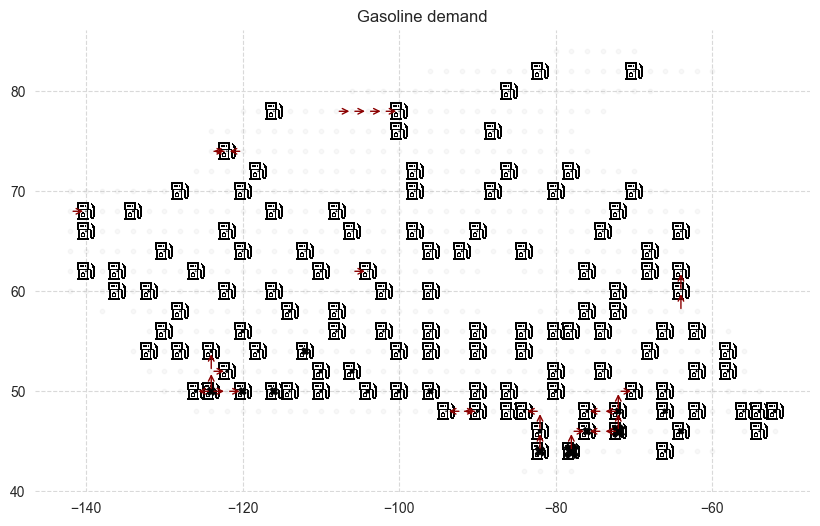

In [68]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(figsize=(10,6))
plt.scatter(sites['lon'], sites['lat'], c='gray', s=10, label='sites', alpha=0.05)

df = sites.loc[sites['demand']>0].copy()
df.reset_index(inplace=True)
df['demand'] = df['demand'].astype(float)
sizes = df['demand']/df['demand'].max() * 100  # Scale sizes for visibility

# Load your custom marker image (PNG)
fig_names = ['gas_demand']
imgs = [mpimg.imread(f"figures/{fig_name}.png") for fig_name in fig_names]  # replace with your PNG file path
# Plot the image markers
for (x, y, s) in zip(df['lon'], df['lat'], sizes):
    imagebox = OffsetImage(img, zoom=0.05)  # adjust zoom scaling
    ab = AnnotationBbox(imagebox, (x, y), frameon=False)
    ax.add_artist(ab)


plt.scatter(x='lon', y='lat', data=df, s=sizes, color='black', label=label[j],  alpha=1, marker='X')
plt.title('Gasoline demand')

df = transp_tech[j].copy()
df.reset_index(inplace=True)
for _, row in df.iterrows():
    ax.annotate(
        '',  # no text
        xy=(row['lon_to'], row['lat_to']),        # arrow head
        xytext=(row['lon_from'], row['lat_from']),# arrow tail
        arrowprops=dict(
            arrowstyle="->",
            color=color[j],
            lw=1,  # line width
            alpha=1
        )
    )



sns.despine(top=True, right=True, left=True, bottom=True)
plt.savefig(f'figures/demand.png', dpi=300)
plt.show()






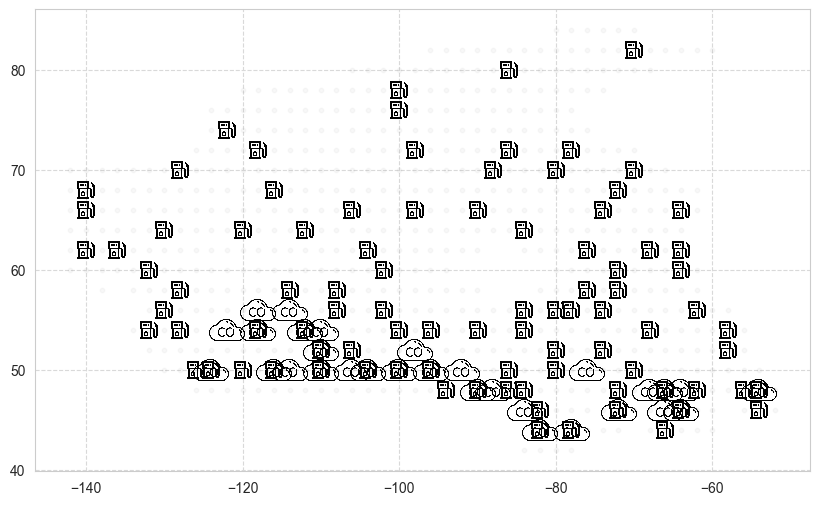

In [60]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox



labels = ['co2_cap', 'gas_demand', 'gas_plant', 
          'h2_plant', 'meth_plant', 'elc_gen']

image_file = ['co2_cap.png', 'gas_demand.png', 'gsl_plant.png', 
              'h2_plant.png', 'methanol_plant.png', 'elc_gen.png']

techs = [co2_cap, gsl_demand, gsl_plant, 
         h2_plant, meth_plant, elc_gen]

color = ['gray', 'brown', 'red', 
         'blue', 'darkred', 'lightblue']

label = ['CO2', 'Gasoline Demand', 'Gasoline Production', 'Hydrogen Production', 'Methanol Production', 'Electricity Gen'] 


df = pd.DataFrame()

image_file = ['co2_cap.png', 'gas_demand.png', 'gsl_plant.png', 
              'h2_plant.png', 'methanol_plant.png', 'elc_gen.png']


for tech in techs:
    df = pd.concat([df, tech], ignore_index=True)
df = df[['tech', 'lon', 'lat', 'flow']]
img_dict = {'CO2_CAP': 'co2_cap.png', 'GSL_DEMAND': 'gas_demand.png', 
           'GSL_PLANT':'gsl_plant.png',  'H2_PLANT': 'h2_plant.png', 
           'METH_PLANT':  'methanol_plant.png','ELC_GEN': 'elc_gen.png'}

images = []
for i in range(len(df)):
    images.append(img_dict[df.loc[i,'tech']])
df['img'] = images

fig, ax = plt.subplots(figsize=(10,6))
plt.scatter(sites['lon'], sites['lat'], c='gray', s=10, label='sites', alpha=0.05)

# Load your custom marker image (PNG)
imgs = [mpimg.imread(f"figures/{fig_name}") for fig_name in df['img']]  # replace with your PNG file path
# Plot the image markers

for (x, y, s, img) in zip(df['lon'], df['lat'], sizes, imgs):
    imagebox = OffsetImage(img, zoom=0.05)  # adjust zoom scaling
    ab = AnnotationBbox(imagebox, (x, y), frameon=False)
    ax.add_artist(ab)







        tech  lon  lat          flow          img
0    CO2_CAP -124   50  2.786783e+05  co2_cap.png
1    CO2_CAP  -96   50  4.805000e+04  co2_cap.png
2    CO2_CAP -112   54  8.757762e+04  co2_cap.png
3    CO2_CAP -106   50  3.017889e+04  co2_cap.png
4    CO2_CAP  -84   46  3.860245e+01  co2_cap.png
..       ...  ...  ...           ...          ...
976  ELC_GEN  -78   82  3.600347e-01  elc_gen.png
977  ELC_GEN  -66   56  9.888182e+00  elc_gen.png
978  ELC_GEN -106   76  3.131258e+01  elc_gen.png
979  ELC_GEN  -78   44  3.290657e+06  elc_gen.png
980  ELC_GEN -120   74  1.574785e+01  elc_gen.png

[981 rows x 5 columns]
CO2_CAP
       tech  lon  lat           flow          img
0   CO2_CAP -124   50  278678.298869  co2_cap.png
1   CO2_CAP  -96   50   48050.000000  co2_cap.png
2   CO2_CAP -112   54   87577.621660  co2_cap.png
3   CO2_CAP -106   50   30178.893566  co2_cap.png
4   CO2_CAP  -84   46      38.602455  co2_cap.png
5   CO2_CAP  -72   46  466666.666741  co2_cap.png
6   CO2_CAP -118  

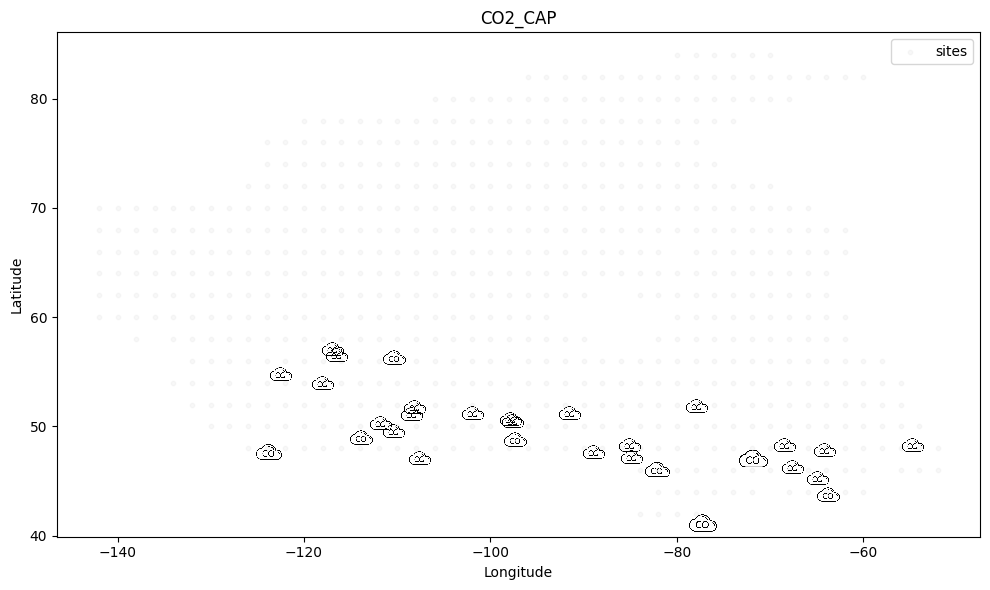

GSL_DEMAND
           tech  lon  lat           flow             img
30   GSL_DEMAND -122   60     799.752076  gas_demand.png
31   GSL_DEMAND -128   54    4804.742081  gas_demand.png
32   GSL_DEMAND -120   64     271.838307  gas_demand.png
33   GSL_DEMAND  -76   46  208041.726500  gas_demand.png
34   GSL_DEMAND  -86   50    2561.509716  gas_demand.png
..          ...  ...  ...            ...             ...
146  GSL_DEMAND -136   62     270.139318  gas_demand.png
147  GSL_DEMAND  -78   72     181.508703  gas_demand.png
148  GSL_DEMAND -100   54    6465.787404  gas_demand.png
149  GSL_DEMAND -110   62    2243.609918  gas_demand.png
150  GSL_DEMAND  -96   64     212.090513  gas_demand.png

[121 rows x 5 columns]


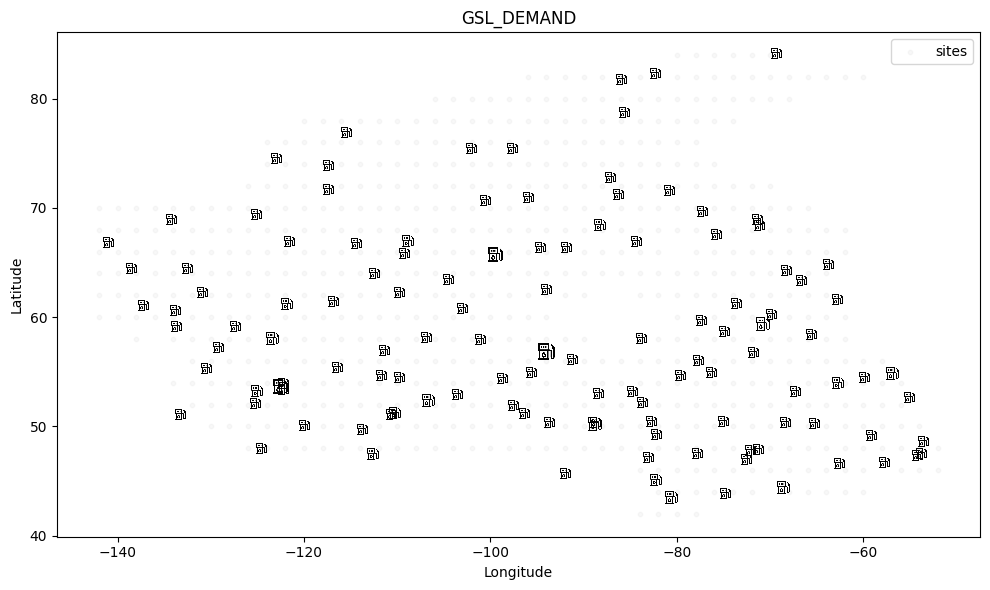

GSL_PLANT
          tech  lon  lat          flow            img
151  GSL_PLANT -110   50   5523.697643  gsl_plant.png
152  GSL_PLANT  -68   64    380.101680  gsl_plant.png
153  GSL_PLANT -140   66    104.818211  gsl_plant.png
154  GSL_PLANT  -62   56    181.178348  gsl_plant.png
155  GSL_PLANT  -68   54    729.857522  gsl_plant.png
..         ...  ...  ...           ...            ...
382  GSL_PLANT  -80   52    837.837736  gsl_plant.png
383  GSL_PLANT -120   56  10930.778543  gsl_plant.png
384  GSL_PLANT  -68   54    729.857555  gsl_plant.png
385  GSL_PLANT -108   58    155.315946  gsl_plant.png
386  GSL_PLANT  -72   68      0.991077  gsl_plant.png

[236 rows x 5 columns]


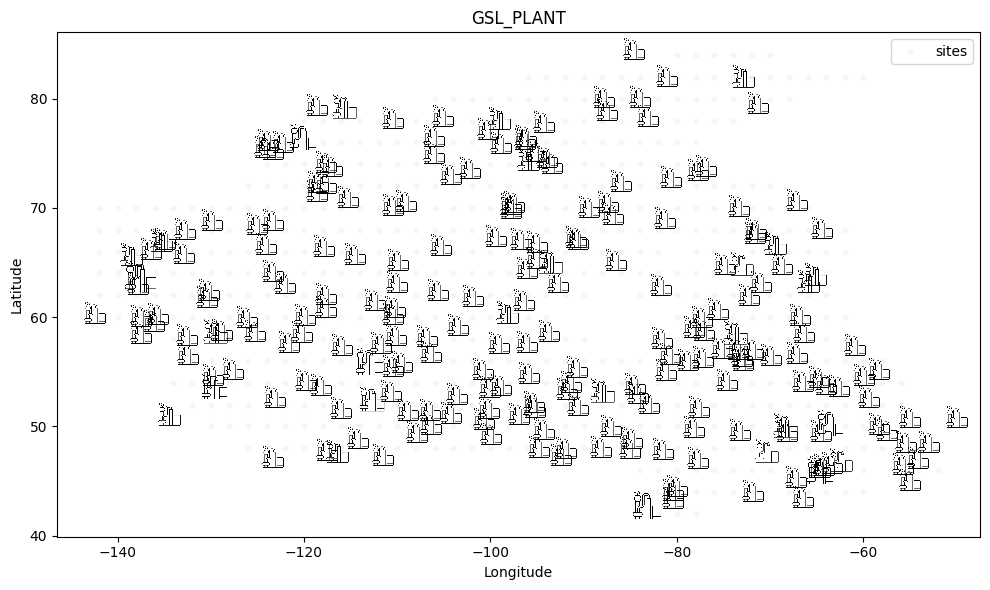

H2_PLANT
         tech  lon  lat          flow           img
387  H2_PLANT  -66   56      0.189862  h2_plant.png
388  H2_PLANT -130   64     13.803675  h2_plant.png
389  H2_PLANT -140   66     15.617913  h2_plant.png
390  H2_PLANT  -64   46   8472.200813  h2_plant.png
391  H2_PLANT -104   62      0.042192  h2_plant.png
..        ...  ...  ...           ...           ...
500  H2_PLANT -108   76      0.601230  h2_plant.png
501  H2_PLANT -138   62      9.985338  h2_plant.png
502  H2_PLANT -112   54  12427.681568  h2_plant.png
503  H2_PLANT  -68   64     56.635150  h2_plant.png
504  H2_PLANT  -80   70     17.136809  h2_plant.png

[118 rows x 5 columns]


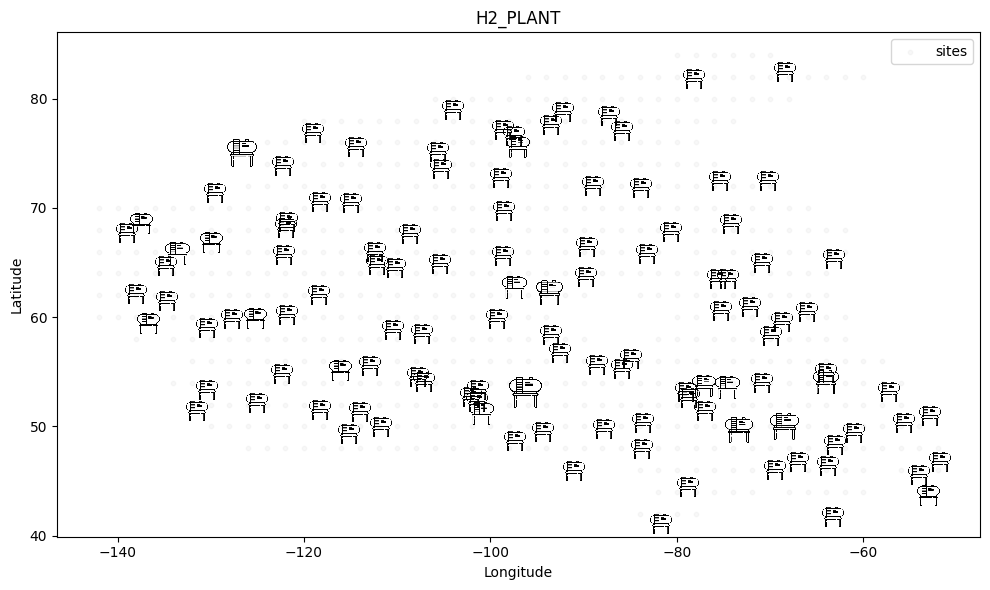

METH_PLANT
           tech  lon  lat          flow                 img
505  METH_PLANT  -68   62     18.016367  methanol_plant.png
506  METH_PLANT -116   68     64.455410  methanol_plant.png
507  METH_PLANT  -80   56     38.050283  methanol_plant.png
508  METH_PLANT -116   50  46142.857139  methanol_plant.png
509  METH_PLANT  -58   54    125.442049  methanol_plant.png
..          ...  ...  ...           ...                 ...
854  METH_PLANT -128   58     65.658861  methanol_plant.png
855  METH_PLANT -106   52  21556.352545  methanol_plant.png
856  METH_PLANT  -90   56     53.553561  methanol_plant.png
857  METH_PLANT  -90   54     93.055064  methanol_plant.png
858  METH_PLANT  -64   58      0.707912  methanol_plant.png

[354 rows x 5 columns]


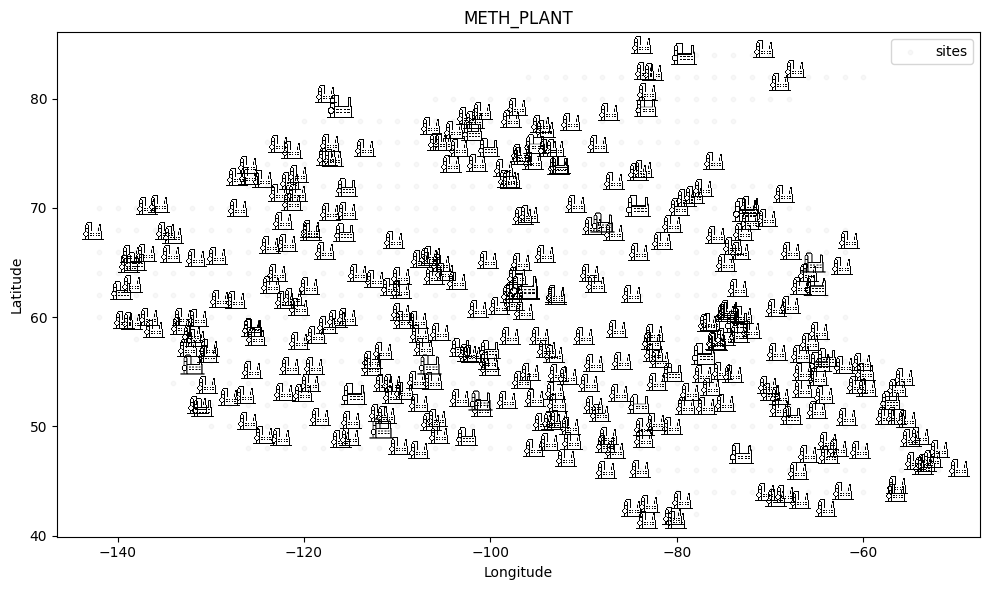

ELC_GEN
        tech  lon  lat          flow          img
859  ELC_GEN -130   64  7.189074e+02  elc_gen.png
860  ELC_GEN -116   60  2.296256e+03  elc_gen.png
861  ELC_GEN  -68   62  1.864105e+02  elc_gen.png
862  ELC_GEN  -80   56  3.936961e+02  elc_gen.png
863  ELC_GEN  -58   54  1.297915e+03  elc_gen.png
..       ...  ...  ...           ...          ...
976  ELC_GEN  -78   82  3.600347e-01  elc_gen.png
977  ELC_GEN  -66   56  9.888182e+00  elc_gen.png
978  ELC_GEN -106   76  3.131258e+01  elc_gen.png
979  ELC_GEN  -78   44  3.290657e+06  elc_gen.png
980  ELC_GEN -120   74  1.574785e+01  elc_gen.png

[122 rows x 5 columns]


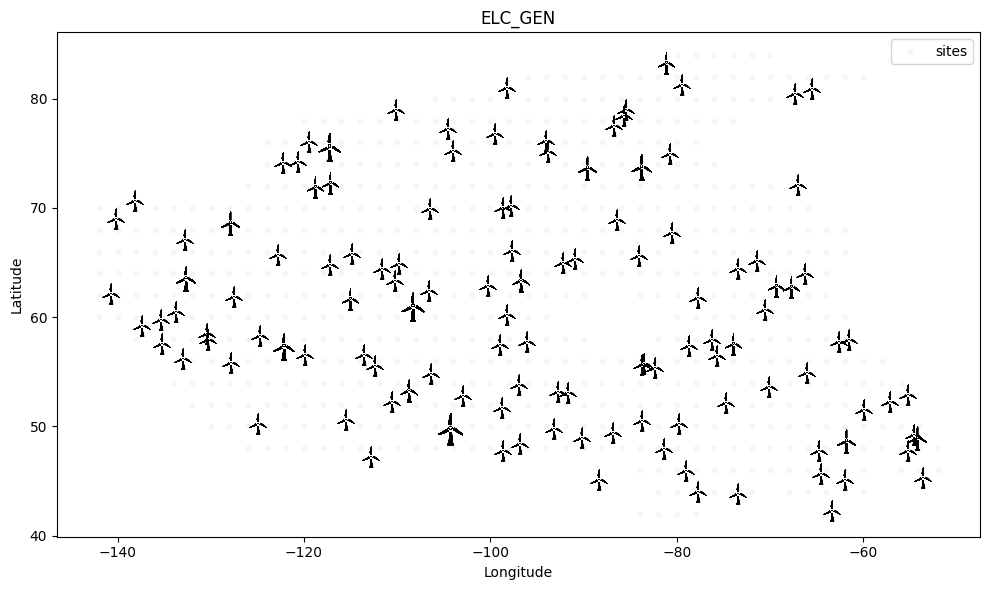

In [14]:
IMG_DIR = "figures"  # folder where the PNGs live

IMG_MAP = {
    "CO2_CAP":      "co2_cap.png",
    "GSL_DEMAND":   "gas_demand.png",
    "GSL_PLANT":    "gsl_plant.png",
    "H2_PLANT":     "h2_plant.png",
    "METH_PLANT":   "methanol_plant.png",
    "ELC_GEN":      "elc_gen.png",
}

# 1) Combine your tech frames
df = pd.concat(techs, ignore_index=True)

# keep only necessary columns and validate
required_cols = {"tech", "lon", "lat", "flow"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in tech DataFrames: {sorted(missing)}")

df = df[["tech", "lon", "lat", "flow"]].copy()

# 2) Map tech -> image filename
df["img"] = df["tech"].map(IMG_MAP)
if df["img"].isna().any():
    unknown = sorted(df.loc[df["img"].isna(), "tech"].unique())
    raise ValueError(f"No image mapping for tech values: {unknown}")

# 3) Choose icon scale (zoom). Here we scale by flow; tweak as needed.
#    If you prefer a fixed zoom, comment these three lines and set zoom=0.05 below.
flow = df["flow"].to_numpy(dtype=float)
if (flow > 0).any():
    fmin, fmax = np.nanmin(flow), np.nanmax(flow)
    # avoid division by zero
    if fmax == fmin:
        zooms = np.full(len(df), 0.05)
    else:
        # map flow to [0.03, 0.10] zoom range (tweak endpoints to taste)
        zooms = 0.03 + 0.07 * (flow - fmin) / (fmax - fmin)
else:
    zooms = np.full(len(df), 0.05)

# 4) Cache images so each file is read once
img_cache = {}
def load_img(fname):
    if fname not in img_cache:
        img_cache[fname] = mpimg.imread(f"{IMG_DIR}/{fname}")
    return img_cache[fname]

all_tech = df.copy()

print(all_tech)

for tech in IMG_MAP.keys():
    print(tech)
    # 5) Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    df = all_tech.loc[all_tech['tech']==tech].copy()
    print(df)
    # Background: all sites (if you want them faint in the back)
    if "lon" in sites.columns and "lat" in sites.columns:
        ax.scatter(sites["lon"] , sites["lat"], c="gray", s=10, alpha=0.05, label="sites")

    # Add icon per row
    for (x, y, fname, zm) in zip(df["lon"], df["lat"], df["img"], zooms):
        try:
            img = load_img(fname)
            imagebox = OffsetImage(img, zoom=float(zm))       # or zoom=0.05 for fixed size
            ab = AnnotationBbox(imagebox, (float(x)+ np.random.uniform(-3,3), float(y)+ + np.random.uniform(-3,3)), frameon=False)
            ax.add_artist(ab)
        except FileNotFoundError:
            # Skip missing files but keep going
            print(f"Warning: file not found: {IMG_DIR}/{fname}")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{tech}")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [86]:
df = pd.DataFrame()

image_file = ['co2_cap.png', 'gas_demand.png', 'gsl_plant.png', 
              'h2_plant.png', 'methanol_plant.png', 'elc_gen.png']


for tech in techs:
    df = pd.concat([df, tech], ignore_index=True)
df = df[['tech', 'lon', 'lat', 'flow']]
img_dict = {'CO2_CAP': 'co2_cap.png', 'GSL_DEMAND': 'gas_demand.png', 
           'GSL_PLANT':'gsl_plant.png',  'H2_PLANT': 'h2_plant.png', 
           'METH_PLANT':  'methanol_plant.png','ELC_GEN': 'elc_gen.png'}

images = []
for i in range(len(df)):
    images.append(img_dict[df.loc[i,'tech']])
df['img'] = images

In [43]:

print(eff.loc[eff['tech']=='GSL_BACKUP','region'].unique().shape)
data['Region'].shape

(123,)


(2259, 2)

NameError: name 'cum_etl' is not defined

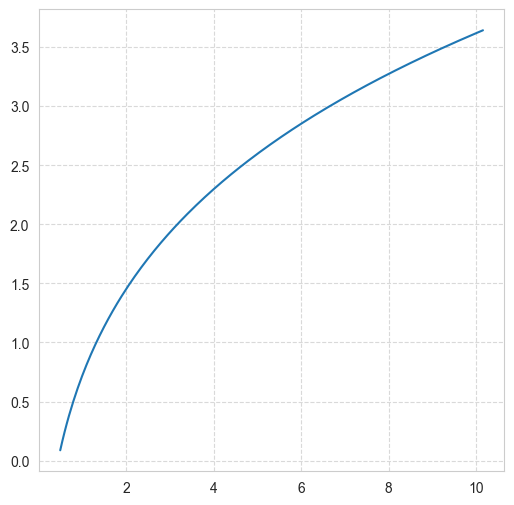

In [51]:
### REPRESENTATION OF ETL



a = 0.05
b = 0.8

cap = np.arange(0.5, 10.2, 0.05)   # Δcap = 0.05
cost = a*(cap**(-b)) 
cum_cost = np.cumsum(cost)

res = 5                                # number of bins
bins = np.logspace(np.log10(cap.min()), np.log10(cap.max()), res + 1)  # 6 edges -> 5 bins
bin_idx = np.digitize(cap, bins, right=False)



# Set the style BEFORE plotting
sns.set_style("whitegrid", {
    "axes.edgecolor": "0.8",
    "grid.color": "0.85",
    "grid.linestyle": "--"
})



plt.figure(figsize=(6,6))
plt.plot(cap, cum_cost)
plt.plot(bins, cum_etl)
# plt.plot(bins, np.cumsum(a*bins**(-b)))

plt.ylabel("Cummulative Investment Cost")
plt.xlabel("Built Capacity")
# plt.xlim((0,10))
# plt.ylim((0,4))



sns.despine(top=True, right=True)
plt.show()


Log-binned summary (5 bins):

 bin  bin_lower  bin_upper  n_points  cap_min  cap_max  cap_geom_mid  unit_cost_at_geom_mid  total_cost_in_bin  cum_total_cost_to_bin  avg_cost_to_bin_upper
   1   0.500000   0.912997         9     0.50     0.90      0.675647               0.068422           0.030705               0.030705               0.033631
   2   0.912997   1.667126        15     0.95     1.65      1.233726               0.042266           0.031033               0.061737               0.037032
   3   1.667126   3.044161        27     1.70     3.00      2.252776               0.026109           0.034781               0.096518               0.031706
   4   3.044161   5.558618        51     3.05     5.55      4.113554               0.016129           0.040574               0.137092               0.024663
   5   5.558618  10.150000        92     5.60    10.15      7.511323               0.009963           0.045076               0.182168               0.017948


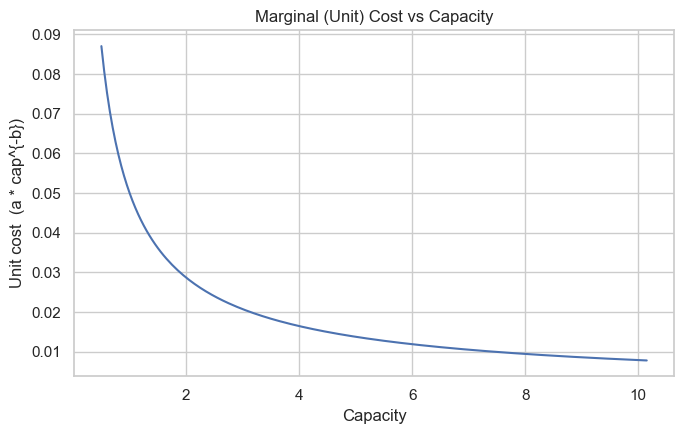

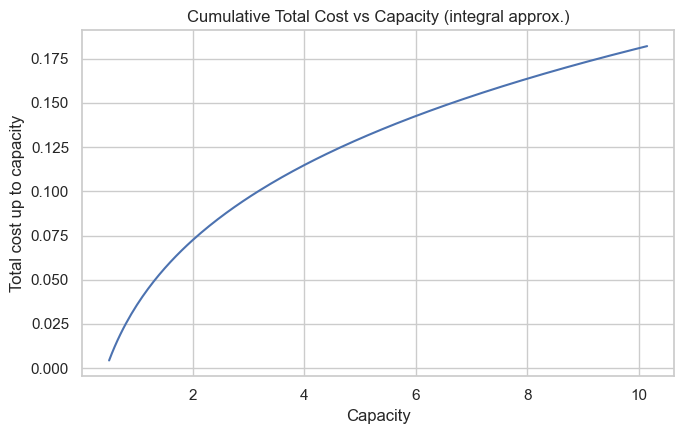

In [ ]:
# etl_cost_model.py
# ETL for a marginal-cost curve: extract arrays, transform with log-binning,
# and load results as a table + diagnostic plots.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

# --------------------
# Extract
# --------------------
a = 0.05
b = 0.8

cap = np.arange(0.5, 10.2, 0.05)      # capacity grid
delta_cap = cap[1] - cap[0]           # step size (0.05)
cost_marginal = a * cap**(-b)         # unit (marginal) cost at each cap
cum_cost_total = np.cumsum(cost_marginal * delta_cap)  # proper cumulative (integral approx.)

# --------------------
# Transform (log-binning)
# --------------------
res = 5                                # number of bins
bins = np.logspace(np.log10(cap.min()), np.log10(cap.max()), res + 1)  # 6 edges -> 5 bins
bin_idx = np.digitize(cap, bins, right=False)

records = []
for i in range(1, len(bins)):  # bins are [bins[i-1], bins[i])
    in_bin = bin_idx == i
    cap_geom_mid = np.sqrt(bins[i-1] * bins[i])         # geometric midpoint (log-representative)
    unit_cost_at_geom_mid = a * cap_geom_mid**(-b)

    if np.any(in_bin):
        cap_bin = cap[in_bin]
        cost_bin = cost_marginal[in_bin]
        total_cost_in_bin = np.sum(cost_bin * delta_cap)
        cap_min = cap_bin.min()
        cap_max = cap_bin.max()
        n_points = cap_bin.size
    else:
        total_cost_in_bin = 0.0
        cap_min = np.nan
        cap_max = np.nan
        n_points = 0

    records.append({
        "bin": i,
        "bin_lower": bins[i-1],
        "bin_upper": bins[i],
        "n_points": n_points,
        "cap_min": cap_min,
        "cap_max": cap_max,
        "cap_geom_mid": cap_geom_mid,
        "unit_cost_at_geom_mid": unit_cost_at_geom_mid,
        "total_cost_in_bin": total_cost_in_bin,
    })

df_bins = pd.DataFrame.from_records(records)
df_bins["cum_total_cost_to_bin"] = df_bins["total_cost_in_bin"].cumsum()
df_bins["avg_cost_to_bin_upper"] = df_bins["cum_total_cost_to_bin"] / df_bins["bin_upper"]

# Optional: round for readability
cols_to_round = ["bin_lower", "bin_upper", "cap_geom_mid", "unit_cost_at_geom_mid",
                 "total_cost_in_bin", "cum_total_cost_to_bin", "avg_cost_to_bin_upper"]
df_pretty = df_bins.copy()
df_pretty[cols_to_round] = df_pretty[cols_to_round].astype(float).round(6)

print("\nLog-binned summary (5 bins):\n")
print(df_pretty.to_string(index=False))

# Optional: export
# df_pretty.to_csv("etl_log_binned_summary.csv", index=False)

# --------------------
# Load (plots)
# --------------------
plt.figure(figsize=(7, 4.5))
plt.plot(cap, cost_marginal)
plt.title("Marginal (Unit) Cost vs Capacity")
plt.xlabel("Capacity")
plt.ylabel("Unit cost  (a * cap^{-b})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(cap, cum_cost_total)
plt.title("Cumulative Total Cost vs Capacity (integral approx.)")
plt.xlabel("Capacity")
plt.ylabel("Total cost up to capacity")
plt.tight_layout()
plt.show()


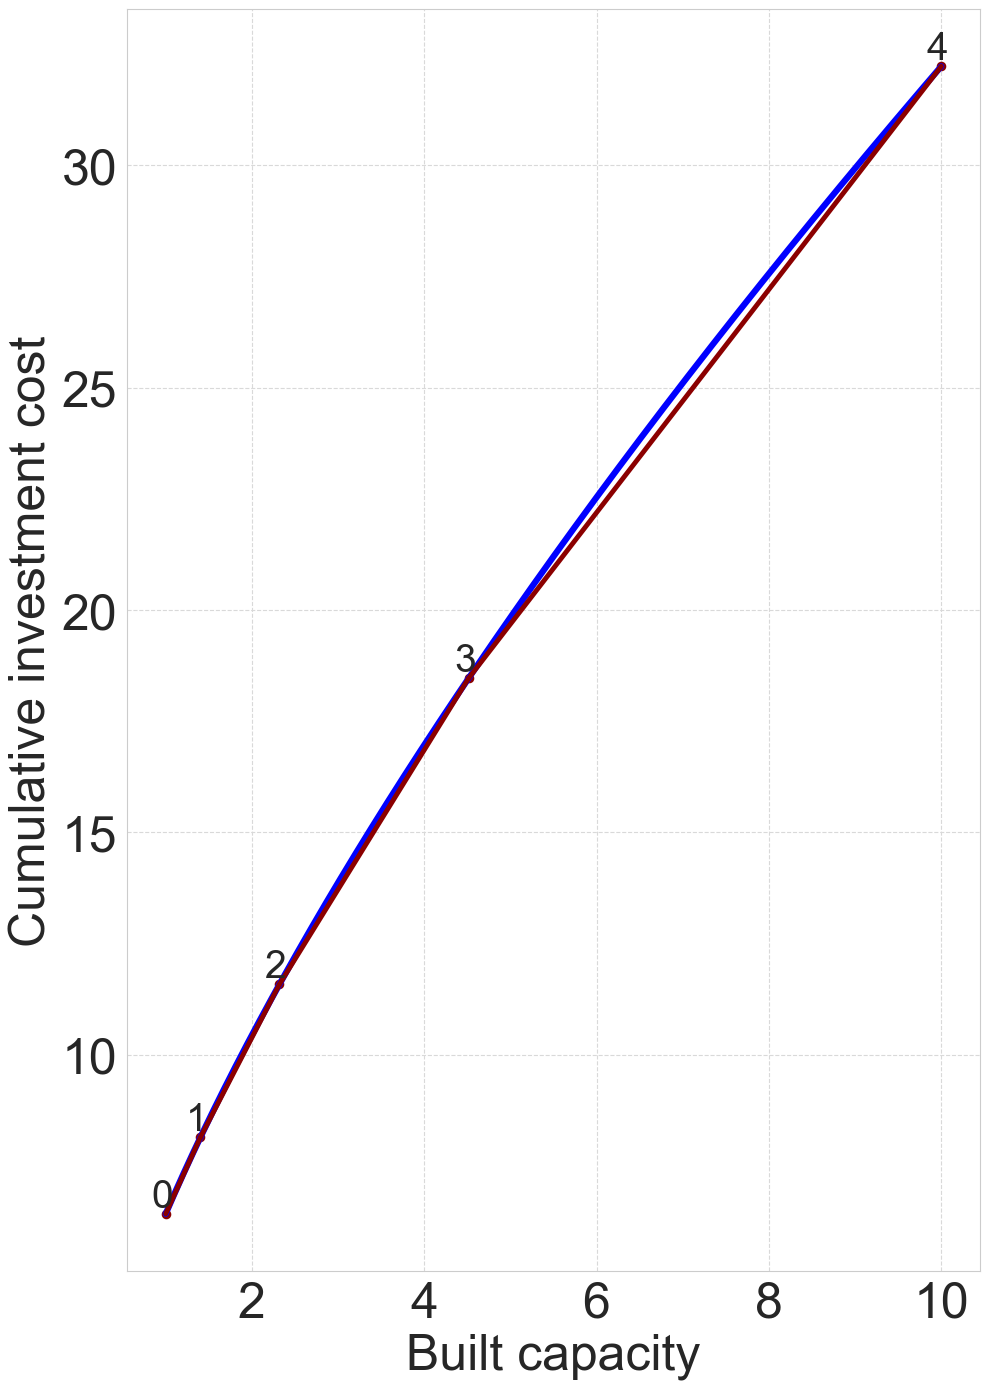

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ----------------------------
# Model parameters (edit here)
# ----------------------------
a = 4.5         # initial unit investment cost at C = 1
b = 0.3          # learning index (progress ratio pr = 2^{-b})
C0 = 1.0         # initial cumulative investment point shown on the curve
Cmax = 10.0      # max cumulative investment to display
N = 4            # number of segments in the PL approximation (Fig. 8.2 uses 4)

# ----------------------------
# Core functions
# ----------------------------
def TC_of_C(C, a=a, b=b):
    """Cumulative investment cost TC(C) = ∫ a*y^{-b} dy = a/(1-b)*C^{1-b} (b != 1)."""
    if np.isclose(b, 1.0):
        raise ValueError("b = 1 not supported in this simple script.")
    return (a / (1.0 - b)) * np.power(C, 1.0 - b)

def C_of_TC(TC, a=a, b=b):
    """Inverse of TC(C): C(TC) = [ (1-b)/a * TC ]^{1/(1-b)}."""
    return np.power(((1.0 - b) / a) * TC, 1.0 / (1.0 - b))

# ----------------------------
# Build vertical (TC-axis) breakpoints in geometric progression
# Each interval width doubles: w_i ∝ 2^{i-1}
# ----------------------------
TC0 = TC_of_C(C0, a, b)
TCmax = TC_of_C(Cmax, a, b)

weights = 2.0 ** np.arange(N)        # [1, 2, 4, 8] for N=4
weights = weights / weights.sum()    # normalize to sum to 1
TC_breaks = [TC0]
running = TC0
for wi in weights:
    running += wi * (TCmax - TC0)
    TC_breaks.append(running)
TC_breaks = np.array(TC_breaks)      # length N+1 from TC0 .. TCmax

# Horizontal breakpoints via inverse mapping
C_breaks = C_of_TC(TC_breaks, a, b)  # C0 .. Cmax

# ----------------------------
# Compute segment lines (Fig. 8.3 style)
# Each segment i goes from (C_{i-1}, TC_{i-1}) to (C_i, TC_i)
# y = a_i + b_i * x  in (C, TC) space
# ----------------------------
@dataclass
class Segment:
    i: int
    C_lo: float
    C_hi: float
    TC_lo: float
    TC_hi: float
    slope_bi: float
    intercept_ai: float

segments = []
for i in range(1, len(C_breaks)):
    C_lo, C_hi = C_breaks[i-1], C_breaks[i]
    TC_lo, TC_hi = TC_breaks[i-1], TC_breaks[i]
    slope = (TC_hi - TC_lo) / (C_hi - C_lo)
    intercept = TC_lo - slope * C_lo
    segments.append(Segment(i=i, C_lo=C_lo, C_hi=C_hi,
                            TC_lo=TC_lo, TC_hi=TC_hi,
                            slope_bi=slope, intercept_ai=intercept))
    
C_grid = np.linspace(C0, Cmax, 600)
TC_grid = TC_of_C(C_grid, a, b)

# ----------------------------
# Figure 8.2 — 4-segment piecewise-linear approximation on (C, TC)
# ----------------------------
plt.figure(figsize=(10, 14))
# Smooth curve for reference
plt.plot(C_grid, TC_grid, lw=4.5, alpha=1, label="Cummulative", color='blue')
# Piecewise linear segments
for s in segments:
    plt.plot([s.C_lo, s.C_hi], [s.TC_lo, s.TC_hi], lw=3.5, color='darkred')
# Breakpoints
plt.scatter(C_breaks, TC_breaks, s=35, color='darkred')
for i, (c, t) in enumerate(zip(C_breaks, TC_breaks)):
    plt.annotate(f"{i}", (c - 0.25, 0.001 + t), textcoords="offset points", xytext=(5,5), fontsize=28)
# plt.title(f"Fig 8.2 — {N}-segment approximation (geometric TC-intervals)")
plt.xlabel("Built capacity", fontsize=36)
plt.ylabel("Cumulative investment cost", fontsize=36)
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)
# plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig('ETL.png', dpi=300 )
plt.show()


Electricity
H2
CO2
Methanol
Gasoline


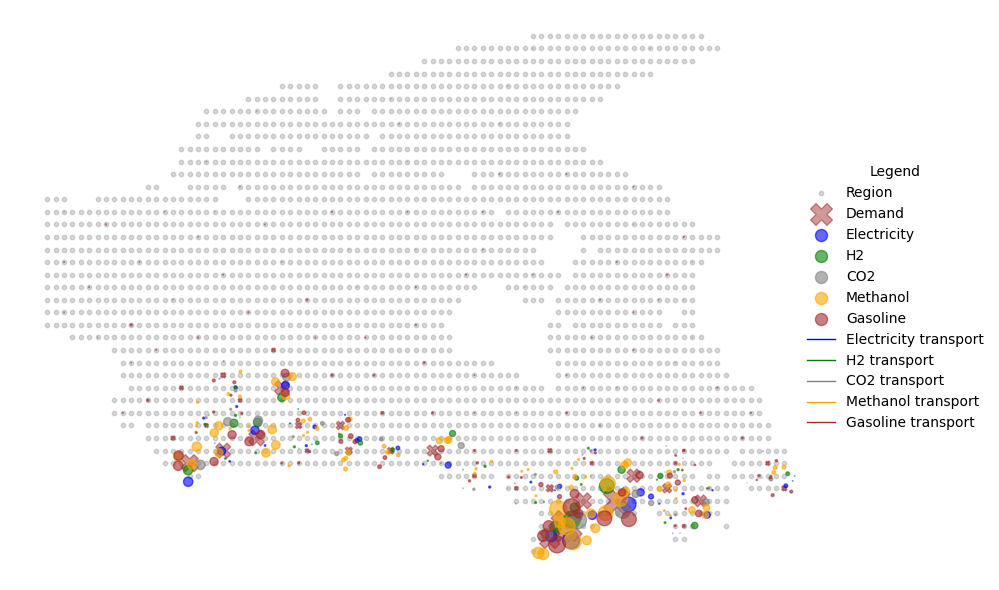

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns  # optional
import db_mgmt as mgmt
import geopandas as gpd


# -------------------------------
# Load data
# -------------------------------
db_path = 'output_files/2026-03-04 2146/CANOE_geospatial.sqlite'
data = mgmt.sqlite_to_dfs(db_path)

sites = pd.read_csv('sites_dict_1.csv')
sites['region'] = sites['site_id']
sites = sites.set_index('region', drop=True)

flowIn  = data['OutputFlowIn'].copy()
flowOut = data['OutputFlowOut'].copy()

# -------------------------------
# Parse region_from / region_to (vectorized)
# -------------------------------
flowOut = flowOut.copy()
flowOut['region_from'] = pd.NA
flowOut['region_to']   = pd.NA

mask_pair = ~flowOut['region'].isin(sites.index)
# split like "AAA-BBB" -> ["AAA","BBB"] only where needed
split = flowOut.loc[mask_pair, 'region'].str.split('-', n=1, expand=True)
flowOut.loc[mask_pair, 'region_from'] = split[0]
flowOut.loc[mask_pair, 'region_to']   = split[1]

# -------------------------------
# Helper: add lon/lat by index (region)
# -------------------------------
def add_site_coords(df, idx_col='region'):
    """Join lon/lat from `sites` using df[idx_col] as index."""
    if idx_col != df.index.name:
        df = df.set_index(idx_col, drop=False)
    return df.join(sites[['lon', 'lat']], how='left')

# -------------------------------
# Slice techs and attach coordinates
# -------------------------------
def slice_with_coords(df, tech_name):
    out = df.loc[df['tech'] == tech_name].copy()
    out = add_site_coords(out, idx_col='region')
    return out

elc_gen   = slice_with_coords(flowOut, 'ELC_GEN')
h2_plant  = slice_with_coords(flowOut, 'H2_PLANT')
co2_cap   = slice_with_coords(flowOut, 'CO2_CAP')
metoh_plant= slice_with_coords(flowOut, 'METOH_PLANT')
gsl_plant = slice_with_coords(flowOut, 'GSL_PLANT')
gsl_demand= slice_with_coords(flowOut, 'GSL_DEMAND')

# Transport links
def add_from_to_coords(df_links):
    """Map lon/lat for region_from and region_to."""
    df = df_links.copy()
    df['lon_from'] = df['region_from'].map(sites['lon'])
    df['lat_from'] = df['region_from'].map(sites['lat'])
    df['lon_to']   = df['region_to'].map(sites['lon'])
    df['lat_to']   = df['region_to'].map(sites['lat'])
    return df

h2_pipe   = add_from_to_coords(flowOut.loc[flowOut.tech=='H2_PIPE'])
gsl_pipe  = add_from_to_coords(flowOut.loc[flowOut.tech=='GSL_PIPE'])
meth_pipe = add_from_to_coords(flowOut.loc[flowOut.tech=='METH_PIPE'])
co2_pipe  = add_from_to_coords(flowOut.loc[flowOut.tech=='CO2_PIPE'])
elc_trans = add_from_to_coords(flowOut.loc[flowOut.tech=='ELC_TRANS'])

# -------------------------------
# Plot config (consistent dictionaries)
# -------------------------------
tech_points = {
    'Electricity' : (elc_gen,   'blue'),
    'H2'          : (h2_plant,  'green'),
    'CO2'         : (co2_cap,   'gray'),
    'Methanol'    : (metoh_plant,'orange'),
    'Gasoline'    : (gsl_plant, 'brown'),
}

tech_links = {
    'Electricity transport' : (elc_trans, 'blue'),
    'H2 transport'          : (h2_pipe,   'green'),
    'CO2 transport'         : (co2_pipe,  'gray'),
    'Methanol transport'    : (meth_pipe, 'orange'),
    'Gasoline transport'    : (gsl_pipe,  'brown'),
}

# Demand for marker 'x'
demand_pts = sites.loc[sites['demand'].fillna(0) > 0, ['lon', 'lat', 'demand']].copy()
if not demand_pts.empty:
    demand_pts['demand'] = demand_pts['demand'].astype(float)
    size_demand = (demand_pts['demand'] / demand_pts['demand'].max()) * 500
else:
    size_demand = pd.Series(dtype=float)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Base regions (faint)
ax.scatter(sites['lon'], sites['lat'], s=10, alpha=0.3, label='Region', c='gray')

# Demand markers
if not demand_pts.empty:
    ax.scatter(demand_pts['lon'], demand_pts['lat'], s=size_demand, alpha=0.4, marker='X', label='Demand', c='darkred')


# Reproducible jitter
rng = np.random.default_rng(42)
jitter_deg = 1.5

# Plot each tech’s point bubbles
for name, (dfp, color) in tech_points.items():
    print(name)
    if dfp.empty or 'flow' not in dfp.columns:
        continue
    dfp_plot = dfp[['lon','lat','flow']].dropna().copy()
    if dfp_plot.empty:
        continue
    dfp_plot['flow'] = pd.to_numeric(dfp_plot['flow'], errors='coerce')
    dfp_plot = dfp_plot.dropna(subset=['flow'])
    if dfp_plot.empty:
        continue

    # jitter
    dfp_plot['lon_plot'] = dfp_plot['lon'] + rng.uniform(-jitter_deg, jitter_deg, size=len(dfp_plot))
    dfp_plot['lat_plot'] = dfp_plot['lat'] + rng.uniform(-jitter_deg, jitter_deg, size=len(dfp_plot))

    size = (dfp_plot['flow'] / dfp_plot['flow'].max()) * 150
    ax.scatter(dfp_plot['lon_plot'], dfp_plot['lat_plot'], s=size, alpha=0.6, label=name, c=color)

# Transport arrows
arrow_jitter = 0.2
for name, (links, color) in tech_links.items():
    if links.empty:
        continue
    links_plot = links[['lon_from','lat_from','lon_to','lat_to']].dropna().copy()
    if links_plot.empty:
        continue
    for _, row in links_plot.iterrows():
        ax.annotate(
            '',
            xy=(row['lon_to'] + rng.uniform(-arrow_jitter, arrow_jitter),
                row['lat_to'] + rng.uniform(-arrow_jitter, arrow_jitter)),
            xytext=(row['lon_from'] + rng.uniform(-arrow_jitter, arrow_jitter),
                    row['lat_from'] + rng.uniform(-arrow_jitter, arrow_jitter)),
            arrowprops=dict(arrowstyle='->', color=color, lw=1, alpha=1)
        )

# # Title, axes style
# ax.set_title('Sites, Demand, and Tech Flows')
# sns.despine(top=True, right=True, left=True, bottom=True)  # optional

# Legend (dedupe)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Optional: include proxies so transport appears in legend even if no arrows visible initially
proxies = [Line2D([0],[0], color=c, lw=1, label=n) for n,(dfp,c) in tech_links.items()]
handles2 = list(by_label.values()) + proxies
labels2  = list(by_label.keys())   + [p.get_label() for p in proxies]
by_label2 = dict(zip(labels2, handles2))
ax.legend(by_label2.values(), by_label2.keys(), title='Legend', frameon=False, loc='upper right', bbox_to_anchor=(1.2, 0.75))

ax.set_xticks([])
ax.set_yticks([])

sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.savefig('figures/Demand.png', dpi=300)
plt.show()